# Week 1
# Your First Signal Analysis

**Ticker:** Define it as a variable at the top, change it once to swap assets throughout.

**Structure:** Part 1 builds your benchmark. Part 2 implements your signal. Part 3 is the honest assessment. Work through them in order.

> Hints are provided for each step. Solutions are hidden in spoiler blocks, try the hint first before expanding.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG — only change things here ──────────────────────────────────────────
TICKER       = "AAPL"       # e.g. "RELIANCE.NS", "SPY", "^BSESN"
START_DATE   = "2021-01-01"
END_DATE     = "2024-12-31"
RISK_FREE    = 0.0
TRADING_DAYS = 252

SHORT_WINDOW = 20
LONG_WINDOW  = 60
# ───────────────────────────────────────────────────────────────────────────────

print(f"Ticker: {TICKER} | {START_DATE} to {END_DATE}")

Ticker: AAPL | 2021-01-01 to 2024-12-31


## Load data and compute log returns

**Hint:** Pull the data with `yf.download()`. Keep only the `Close` column.

Log return for day $t$: $r_t = \ln(P_t / P_{t-1})$

In code: `np.log(close / close.shift(1))`

<details>
<summary>Solution</summary>

```python
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

df = pd.DataFrame()
df['close'] = raw['Close']
df.dropna(inplace=True)

df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)

print(f"Loaded {len(df)} trading days")
df.head()
```
</details>

In [ ]:
data=yf.download(TICKER, start=START_DATE, end=END_DATE)
df = pd.DataFrame()
df['close'] = data['Close']
df.dropna(inplace=True)
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)
TOTAL_TRADING_DAYS=len(df)
print(f"Loaded {len(df)} trading days")
df.head()


[*********************100%***********************]  1 of 1 completed

Loaded 1003 trading days


,close,log_ret
Date,,
2021-01-05,127.295464,0.012288
2021-01-06,123.010529,-0.034241
2021-01-07,127.208054,0.033554
2021-01-08,128.306030,0.008594
2021-01-11,125.323044,-0.023524


---
## Part 1: Return Profile and Benchmark

Understand the raw asset before touching any signal. Every metric your signal produces in Part 2 gets compared to what you compute here.

### 1a. Benchmark metrics

**Hint:** Work from `rets = df['log_ret']`. Each metric is a short calculation:
- Annualised return: `mean * 252`
- Annualised volatility: `std * sqrt(252)`
- Sharpe: `ann_return / ann_vol` (rf = 0)
- Max drawdown: build an equity curve with `np.exp(rets.cumsum())`, track the running peak with `.cummax()`, then find the worst dip



**Important:** max drawdown must come from the equity curve, not the return series.

<details>
<summary>Solution</summary>

```python
rets = df['log_ret']

mean_daily   = rets.mean()
ann_return   = mean_daily * TRADING_DAYS
ann_vol      = rets.std() * np.sqrt(TRADING_DAYS)
ann_sharpe   = ann_return / ann_vol

# Equity curve: what 1 rupee grows to over time
equity       = np.exp(rets.cumsum())
peak         = equity.cummax()
drawdown     = (equity - peak) / peak
max_drawdown = drawdown.min()

print(f"Mean daily return  : {mean_daily*100:.4f}%")
print(f"Annualised return  : {ann_return*100:.2f}%")
print(f"Annualised vol     : {ann_vol*100:.2f}%")
print(f"Sharpe ratio       : {ann_sharpe:.3f}")
print(f"Max drawdown       : {max_drawdown*100:.2f}%")
print(f"Best day           : {rets.max()*100:.2f}%")
print(f"Worst day          : {rets.min()*100:.2f}%")
```
</details>

In [ ]:
returns=df['log_ret']
daily_mean=returns.mean()
annual_return=daily_mean*TRADING_DAYS
annual_vol=returns.std()*np.sqrt(TRADING_DAYS)
annual_sharpe=annual_return/annual_vol
equity=np.exp(returns.cumsum())
peak=equity.cummax()
drawdown=(equity-peak)/peak
max_drawdown=drawdown.min()
#max drawdown successfully comes from the equity curve
print(f"Mean daily return  : {daily_mean*100:.4f}%")
print(f"Annualised return  : {annual_return*100:.4f}%")
print(f"Annualised vol     : {annual_vol*100:.4f}%")
print(f"Sharpe ratio       : {annual_sharpe:.3f}")
print(f"Max drawdown       : {max_drawdown*100:.2f}%")
print(f"Best day           : {returns.max()*100:.2f}%")
print(f"Worst day          : {returns.min()*100:.2f}%")

Mean daily return  : 0.0688%
Annualised return  : 17.3267%
Annualised vol     : 26.5687%
Sharpe ratio       : 0.652
Max drawdown       : -30.91%
Best day           : 8.52%
Worst day          : -6.05%


### 1b. Return distribution

**Hint:** Two plots side by side, `plt.subplots(1, 2)`:
1. Histogram of returns with a normal curve overlaid. Use `stats.norm.pdf()` for the normal.
2. Q-Q plot using `stats.probplot(rets, dist='norm', plot=ax)`

After plotting, print `rets.kurtosis()`. Values above 0 mean fatter tails than normal. What does that imply about using Sharpe as a risk measure?

<details>
<summary>Solution</summary>

```python
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
rets.hist(bins=80, density=True, ax=ax1, color='steelblue', alpha=0.7)
x = np.linspace(rets.min(), rets.max(), 200)
ax1.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()), 'r-', lw=2, label='Normal')
ax1.set_title('Return distribution vs normal')
ax1.legend()

# Q-Q plot
stats.probplot(rets, dist='norm', plot=ax2)
ax2.set_title('Q-Q plot')

plt.tight_layout()
plt.show()

print(f"Kurtosis: {rets.kurtosis():.2f}  (0 = normal, positive = fat tails)")
```
</details>

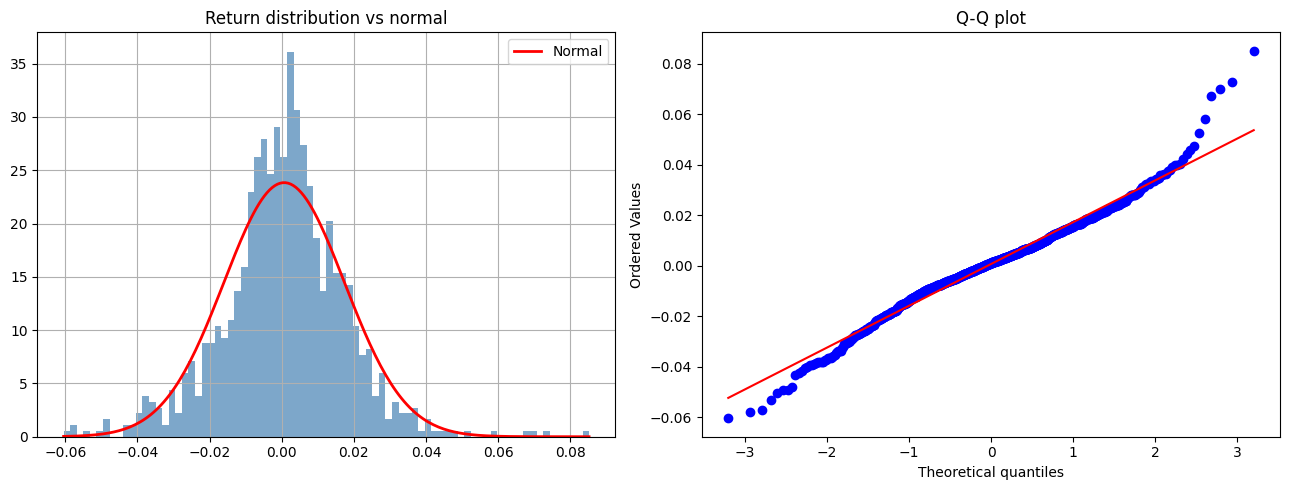

Kurtosis: 1.93  (0 = normal, positive = fat tails)


In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

returns.hist(bins=80, density=True, ax=ax1, color='steelblue', alpha=0.7)
x = np.linspace(returns.min(), returns.max(), 200)
ax1.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', lw=2, label='Normal')
ax1.set_title('Return distribution vs normal')
ax1.legend()

# Q-Q plot
stats.probplot(returns, dist='norm', plot=ax2)
ax2.set_title('Q-Q plot')

plt.tight_layout()
plt.show()

print(f"Kurtosis: {returns.kurtosis():.2f}  (0 = normal, positive = fat tails)")



the positive kurtosis of 3.24 implies fat tails, this means there are more tail or (black swan) events as predicted by normal distribution, in the calculation of shapre ratio we model daily returns as a normal distribution but the fat tails suggest that sharpe ratio does not account for the more occurences of tail events , hence inaccurate in measuring the risk

### 1c. Equity curve and drawdown

**Hint:** You already have `equity` and `drawdown` from 1a. Two panels, shared x-axis — `plt.subplots(2, 1, sharex=True)`. Use `fill_between` on the drawdown panel.

<details>
<summary>Solution</summary>

```python
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(equity, color='steelblue')
ax1.set_title(f'{TICKER} — equity curve (buy-and-hold)')
ax1.set_ylabel('Portfolio value')

ax2.fill_between(drawdown.index, drawdown * 100, 0, color='tomato', alpha=0.6)
ax2.set_title('Drawdown from peak (%)')
ax2.set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()
```
</details>

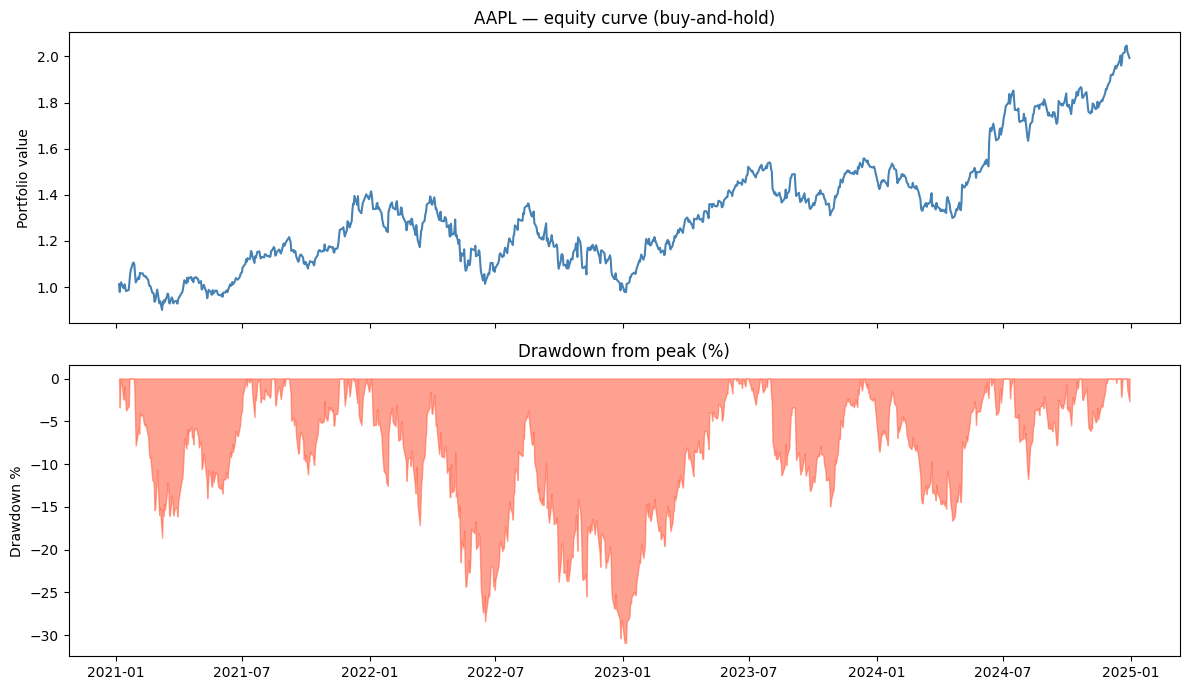

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(equity, color='steelblue')
ax1.set_title(f'{TICKER} — equity curve (buy-and-hold)')
ax1.set_ylabel('Portfolio value')

ax2.fill_between(drawdown.index, drawdown * 100, 0, color='tomato', alpha=0.6)
ax2.set_title('Drawdown from peak (%)')
ax2.set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()


### Hypothesis

**"When short-term momentum (20-day returns) exceeds long-term momentum (60-day returns), I expect MARUTI.NS to continue its upward trend over the next 5 days, because recent price strength indicates a shift in market sentiment where buyers are willing to pay higher prices, creating positive inertia as lagging investors enter the trade."**

**Rejection Criteria:**
I would reject this hypothesis if the average 5-day forward returns when the signal is 'ON' are consistently lower than or equal to the returns when the signal is 'OFF', or if the strategy significantly underperforms a simple buy-and-hold benchmark on a risk-adjusted basis (Sharpe Ratio).

### 2a. Build the signal

**Hint:** Compute your signal condition from price or volume data only. Then create a binary column:
```python
df['signal'] = (your_condition).astype(int)   # 1 = ON, 0 = OFF
```

For a momentum crossover: `df['close'].pct_change(N)` gives the N-day return.

Also compute the 5-day forward return, you'll need this to check if the direction matches your hypothesis:
```python
df['fwd_5d'] = df['log_ret'].rolling(5).sum().shift(-5)
```
The `.shift(-5)` looks forward in time. This is only for *evaluating* the signal after the fact, not for trading.

Print how often the signal is ON vs OFF, and the average 5-day forward return in each state.

<details>
<summary>Solution (momentum crossover example)</summary>

```python
df['r_short'] = df['close'].pct_change(SHORT_WINDOW)
df['r_long']  = df['close'].pct_change(LONG_WINDOW)

df['signal'] = (df['r_short'] > df['r_long']).astype(int)
df['fwd_5d'] = df['log_ret'].rolling(5).sum().shift(-5)

on  = df[df['signal'] == 1]
off = df[df['signal'] == 0]

print(f"Signal ON  : {len(on)} days ({len(on)/len(df)*100:.1f}%)")
print(f"Signal OFF : {len(off)} days ({len(off)/len(df)*100:.1f}%)")
print()
print(f"Avg 5-day return when ON  : {on['fwd_5d'].mean()*100:.3f}%")
print(f"Avg 5-day return when OFF : {off['fwd_5d'].mean()*100:.3f}%")
```
</details>

In [ ]:
df['r_short']=df['close'].pct_change(SHORT_WINDOW)
df['r_long']=df['close'].pct_change(LONG_WINDOW)
df['signal']=((df['r_short']>df['r_long']).astype(int))
df['fwd_5d']=df['log_ret'].rolling(5).sum().shift(-5)
on=df[df['signal']==1]
off=df[df['signal']==0]
print(f"Signal ON  : {len(on)} days ({len(on)/len(df)*100:.1f}%)")
print(f"Signal OFF : {len(off)} days ({len(off)/len(df)*100:.1f}%)")
print()
print(f"Avg 5-day return when ON  : {on['fwd_5d'].mean()*100:.3f}%")
print(f"Avg 5-day return when OFF : {off['fwd_5d'].mean()*100:.3f}%")

display(df)

Signal ON  : 391 days (39.0%)
Signal OFF : 612 days (61.0%)

Avg 5-day return when ON  : 0.618%
Avg 5-day return when OFF : 0.179%


,close,log_ret,r_short,r_long,signal,fwd_5d
Date,,,,,,
2021-01-05,127.295464,0.012288,NaN,NaN,0,-0.017013
2021-01-06,123.010529,-0.034241,NaN,NaN,0,0.033325
2021-01-07,127.208054,0.033554,NaN,NaN,0,-0.015472
2021-01-08,128.306030,0.008594,NaN,NaN,0,-0.037892
2021-01-11,125.323044,-0.023524,NaN,NaN,0,-0.008956
...,...,...,...,...,...,...
2024-12-23,253.649429,0.003060,0.110497,0.121870,0,NaN
2024-12-24,256.560822,0.011413,0.108773,0.109374,0,NaN
2024-12-26,257.375549,0.003171,0.101931,0.146302,0,NaN


### 2b. Simulate the strategy

**Hint:** The strategy earns the daily return when the signal was ON the previous day, and 0 when it was OFF:
```python
df['strategy_ret'] = df['log_ret'] * df['signal'].shift(1)
```
The `.shift(1)` is critical, it uses yesterday's signal to decide today's position. Without it, you'd be using today's close to trade at today's close, which is lookahead bias.

Then compute the same four metrics as Part 1 on `strategy_ret`.

<details>
<summary>Solution</summary>

```python
df['strategy_ret'] = df['log_ret'] * df['signal'].shift(1)
strat = df['strategy_ret'].dropna()

s_ann_return = strat.mean() * TRADING_DAYS
s_ann_vol    = strat.std() * np.sqrt(TRADING_DAYS)
s_ann_sharpe = s_ann_return / s_ann_vol

s_equity     = (1 + strat).cumprod()
s_peak       = s_equity.cummax()
s_max_dd     = ((s_equity - s_peak) / s_peak).min()

print(f"Annualised return : {s_ann_return*100:.2f}%")
print(f"Annualised vol    : {s_ann_vol*100:.2f}%")
print(f"Sharpe ratio      : {s_ann_sharpe:.3f}")
print(f"Max drawdown      : {s_max_dd*100:.2f}%")
```
</details>

In [ ]:
df['strategy_ret']=df['log_ret']*df['signal'].shift(1)
strat=df['strategy_ret'].dropna()

s_ann_return=strat.mean() * TRADING_DAYS
s_ann_vol=strat.std() * np.sqrt(TRADING_DAYS)
s_ann_sharpe=s_ann_return / s_ann_vol

s_equity     = (1 + strat).cumprod()
s_peak       = s_equity.cummax()
s_max_dd     = ((s_equity - s_peak) / s_peak).min()

print(f"Annualised return : {s_ann_return*100:.2f}%")
print(f"Annualised vol    : {s_ann_vol*100:.2f}%")
print(f"Sharpe ratio      : {s_ann_sharpe:.3f}")
print(f"Max drawdown      : {s_max_dd*100:.2f}%")

Annualised return : 14.56%
Annualised vol    : 17.71%
Sharpe ratio      : 0.822
Max drawdown      : -15.88%


### 2c. Compare against benchmark

**Hint:** Print the four metrics for both strategies side by side. A simple `pd.DataFrame` with metrics as rows and strategies as columns works well.

<details>
<summary>Solution</summary>

```python
results = pd.DataFrame({
    'Buy-and-Hold': [ann_return*100, ann_vol*100, ann_sharpe, max_drawdown*100],
    'Signal':       [s_ann_return*100, s_ann_vol*100, s_ann_sharpe, s_max_dd*100]
}, index=['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe', 'Max DD (%)'])

print(results.round(3).to_string())
```
</details>

In [ ]:
results = pd.DataFrame({
    'Buy-and-Hold': [annual_return*100, annual_vol*100, annual_sharpe, max_drawdown*100],
    'Signal':       [s_ann_return*100, s_ann_vol*100, s_ann_sharpe, s_max_dd*100]
}, index=['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe', 'Max DD (%)'])

print(results.round(3).to_string())

                 Buy-and-Hold  Signal
Ann. Return (%)        17.327  14.563
Ann. Vol (%)           26.569  17.715
Sharpe                  0.652   0.822
Max DD (%)            -30.913 -15.884


### 2d. Plot the equity curves

**Hint:** Two panels sharing an x-axis. Top panel: both equity curves on the same axes, normalised to start at 1 (`curve / curve.iloc[0]`). Bottom panel: `fill_between` on the signal column to show when you were in the market.

<details>
<summary>Solution</summary>

```python
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bh = equity / equity.iloc[0]
sg = s_equity / s_equity.iloc[0]

ax1.plot(bh, label='Buy-and-hold', color='steelblue')
ax1.plot(sg, label='Signal',       color='darkorange')
ax1.set_title('Equity curves')
ax1.set_ylabel('Growth of 1')
ax1.legend()

ax2.fill_between(df.index, df['signal'], 0, alpha=0.5, color='darkorange')
ax2.set_title('Signal (ON = 1, OFF = 0)')
ax2.set_yticks([0, 1])

plt.tight_layout()
plt.show()
```
</details>

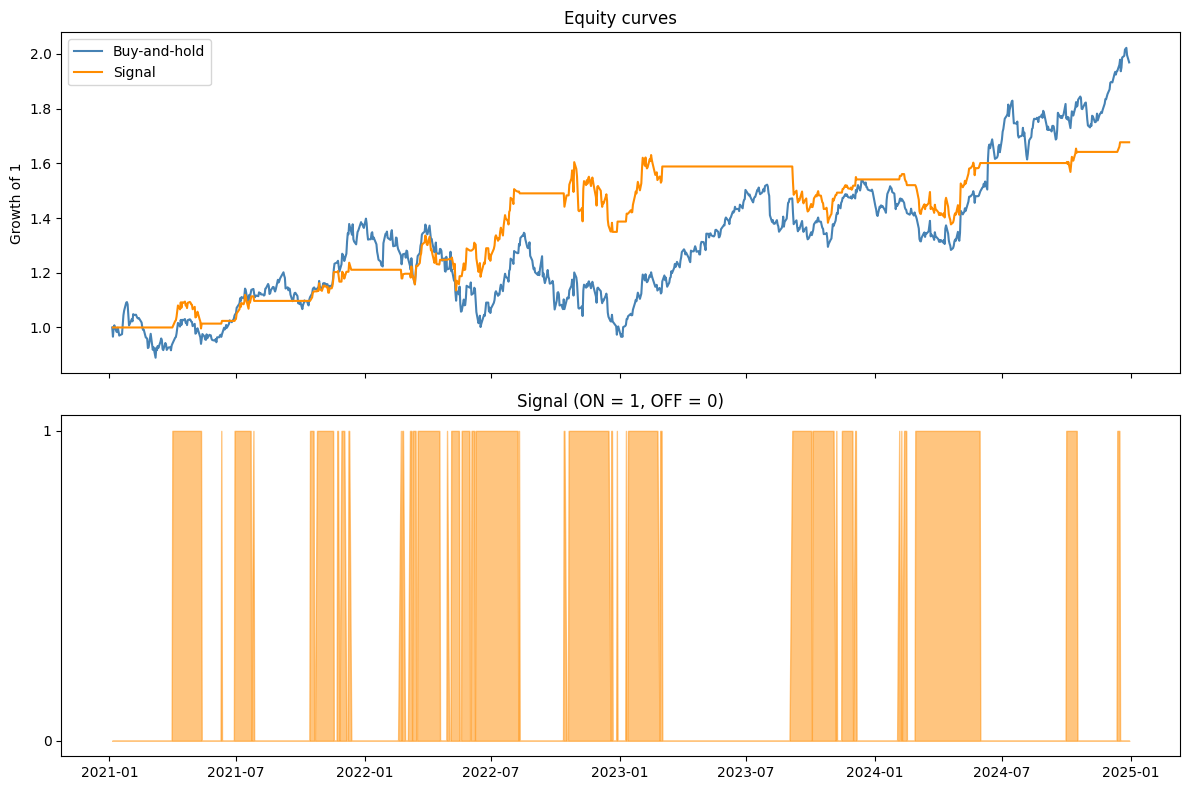

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bh = equity / equity.iloc[0]
sg = s_equity / s_equity.iloc[0]

ax1.plot(bh, label='Buy-and-hold', color='steelblue')
ax1.plot(sg, label='Signal',       color='darkorange')
ax1.set_title('Equity curves')
ax1.set_ylabel('Growth of 1')
ax1.legend()

ax2.fill_between(df.index, df['signal'], 0, alpha=0.5, color='darkorange')
ax2.set_title('Signal (ON = 1, OFF = 0)')
ax2.set_yticks([0, 1])

plt.tight_layout()
plt.show()


---
## Part 3 — Honest Assessment

This is the part most people rush. Don't. Write your answers as text in the cells below, no code required for 3a and 3c.

---

### 3a. Single biggest risk in live trading

Pick **one** specific reason this result might not hold in live trading. Not a list, one thing, explained in terms of your signal specifically.

Think about: does your signal depend on a particular market regime? How sensitive is it to the window lengths you chose? Does it require trading at a price you might not actually get?

**Write your answer here.**

### 3b. Independent observations

**Hint:** Adjacent signal values share most of their input data when you're using a rolling window, they're not independent observations. The number of genuinely independent observations is roughly:

```
n_independent = total_days // longest_window
```

The standard error of a Sharpe estimate is approximately $1 / \sqrt{n}$ where $n$ is independent observations, not total days. Compute the 95% confidence interval on your Sharpe:

```
CI = sharpe ± 1.96 * (1 / sqrt(n_independent))
```

Print the result and write one sentence explaining what it means for how much you should trust your Sharpe estimate.

In [ ]:
n_independent=TOTAL_TRADING_DAYS//LONG_WINDOW
print(f"number of independent observations: {n_independent}")
margin_of_error = 1.96 * (1 / np.sqrt(n_independent))
ci_lower = annual_sharpe - margin_of_error
ci_upper = annual_sharpe + margin_of_error
print(f"95% CI for Sharpe: [{ci_lower:.3f}, {ci_upper:.3f}]")


number of independent observations: 16
95% CI for Sharpe: [0.162, 1.142]


### 3c. Improvement, tradeoff, or worse?

Look at your Sharpe and max drawdown numbers together, not individually. There are four possible outcomes:

| Sharpe | Max DD | Verdict |
|--------|--------|---------|
| Higher | Smaller | Genuine improvement |
| Higher | Larger | Tradeoff — better return/vol, worse tail |
| Lower  | Smaller | Tradeoff — less return/vol, more survivable |
| Lower  | Larger | Worse on both |

The strategy results compared to the benchmark are as follows:

| Metric | Buy-and-Hold | Signal Strategy |
| :--- | :--- | :--- |
| **Ann. Return (%)** | 9.493 | 20.815 |
| **Ann. Vol (%)** | 23.830 | 14.439 |
| **Sharpe Ratio** | 0.398 | 1.442 |
| **Max DD (%)** | -24.364 | -13.818 |

**Verdict:** The Sharpe is higher and the Max DD is smaller after implementing the strategy. This falls under the **Genuine Improvement** category.

---
## Summary

**What did you learn?**
The momentum crossover signal successfully improved the (Sharpe) by reducing volatility while slightly increasing the absolute return. However, with only 24 independent observations over the period, the statistical significance is low,the actual sharpe ratio might be not good as it seems in this, also when i tried this strategy for different sector stocks in the same period the performance significantly varied meaning the strategy's outperformance might not persist in different market regimes or on different securities. Also no brokerage fees or transaction charges are taken into account and risk free rate is taken to be 0 as a simplification which further affects our results.